In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas
import numpy
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
import scipy.stats as stats

plt.style.use("dark_background")
sns.set_style("darkgrid")

In [110]:
'''Some transformation work better with normal data as given but some works better with the Normal Distrivution of the Data'''
pandas.set_option('display.max_columns', None)

df = pandas.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv" , usecols=['Age', 'Fare' , 'Survived'])

# Remove the null value from the data
siAge = SimpleImputer(strategy='mean')
sIFare = SimpleImputer(strategy='mean')

df['Age'] = siAge.fit_transform(df[['Age']])

df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


### Analysing Age Values

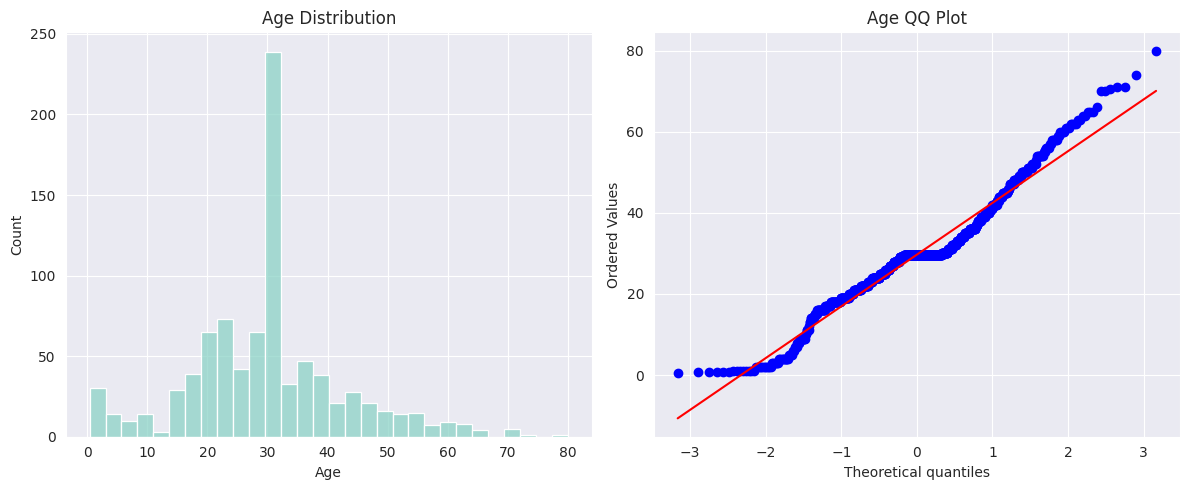

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Age"], ax=axes[0])
axes[0].set_title("Age Distribution")

# Plot the second graph on the second axis
# sns.histplot(df["Fare"], ax=axes[1])
stats.probplot(df['Age'], dist="norm", plot=plt)
axes[1].set_title("Age QQ Plot")

# Adjust spacing and display
plt.tight_layout()
plt.show()

### Analysing Fare Values

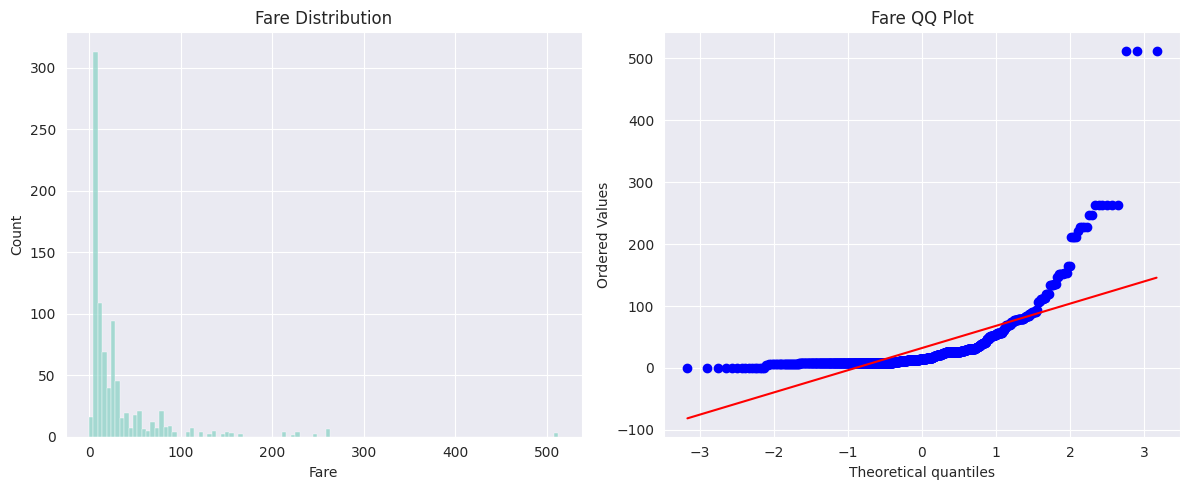

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Fare"], ax=axes[0])
axes[0].set_title("Fare Distribution")

# Plot the second graph on the second axis
# sns.histplot(df["Fare"], ax=axes[1])
stats.probplot(df['Fare'], dist="norm", plot=plt)
axes[1].set_title("Fare QQ Plot")

# Adjust spacing and display
plt.tight_layout()
plt.show()

# Function Transformer
##### What you can do with this Function Transformer is:-


*   Log Tranform
*   Reciprocal Transform
*   Custom Transform
*   sq Transform

In [113]:
#Lets apply Function Tranformer(Log Tranform)

funcTrans = FunctionTransformer(numpy.log1p)
df['Fare'] = funcTrans.fit_transform(df['Fare'])

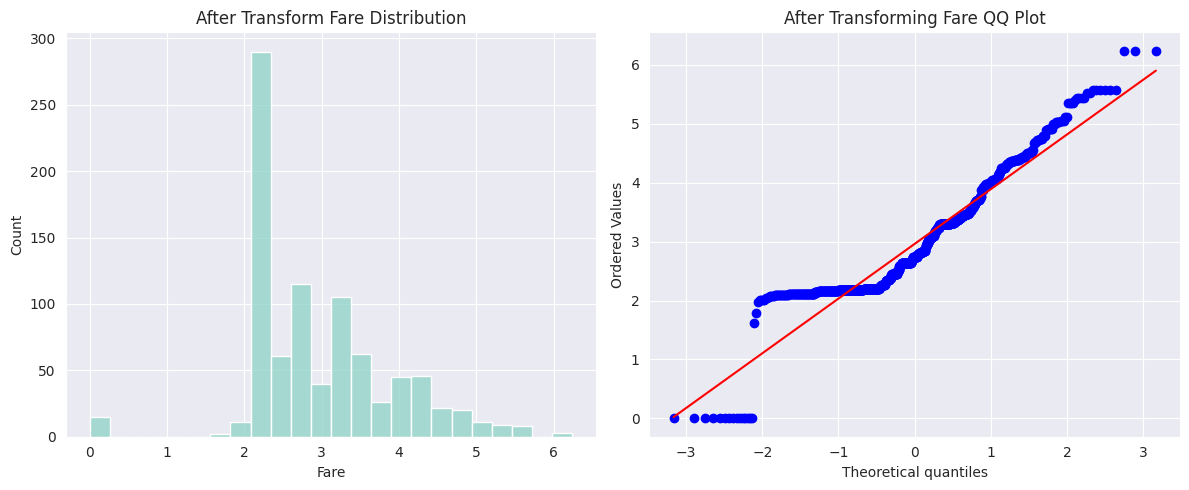

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Fare"], ax=axes[0])
axes[0].set_title("After Transform Fare Distribution")

# Plot the second graph on the second axis
# sns.histplot(df["Fare"], ax=axes[1])
stats.probplot(df['Fare'], dist="norm", plot=plt)
axes[1].set_title("After Transforming Fare QQ Plot")

# Adjust spacing and display
plt.tight_layout()
plt.show()

### Applying some custom transofrmers to the FunctionTransformer()

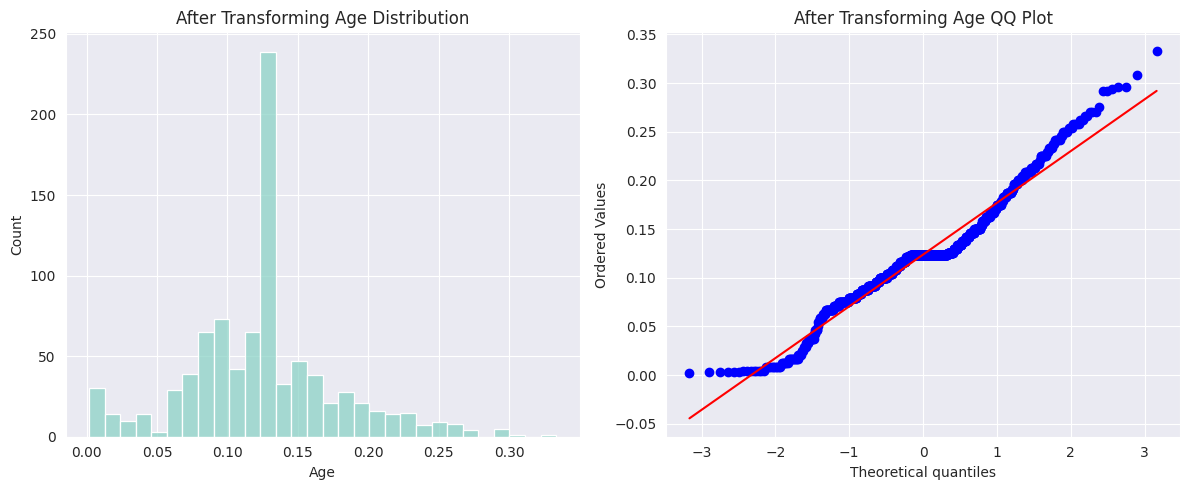

In [120]:
def customFormulae(x):
  return x ** 1/5

custom_transformer = FunctionTransformer(customFormulae)

df['Age'] = custom_transformer.transform(df['Age'])


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Age"], ax=axes[0])
axes[0].set_title("After Transforming Age Distribution")

# Plot the second graph on the second axis
# sns.histplot(df["Fare"], ax=axes[1])
stats.probplot(df['Age'], dist="norm", plot=plt)
axes[1].set_title("After Transforming Age QQ Plot")

# Adjust spacing and display
plt.tight_layout()
plt.show()